<a href="https://colab.research.google.com/github/guedes87/ciencia-de-dados-e-analytics-PUCRIO/blob/main/Machine%20Learning%20%26%20Analytics/MVP_ML_%26_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MVP: *Machine Learning & Analytics*

**Autor:** Thiago Rodrigues Guedes da Silva  

**Data:** 27/08/2025

**Matrícula:** 4052025000113

**Dataset:** Ex: [Global Coffee Health Dataset](https://www.kaggle.com/datasets/uom190346a/global-coffee-health-dataset?resource=download)




## 1 - Escopo, objetivo e definição do problema

O *dataset* contém 10.000 registros sintéticos que refletem padrões reais de consumo de café, comportamento de sono e resultados de saúde em 20 países. Inclui dados de ingestão diária de café, níveis de cafeína, duração e qualidade do sono, IMC, frequência cardíaca, estresse, atividade física, problemas de saúde, ocupação, tabagismo e consumo de álcool.

**Objetivo:** Desenvolver um modelo de *Machine Learning* para **prever** a ocorrência de problemas de saúde (*Health_Issues*) com base em outras variáveis do estilo de vida.




## 2 - Bibliotecas


In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as ms
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import warnings
warnings.filterwarnings('ignore') # Para simplificar a visualização, ignorando warnings



## 3 - Dataset



In [89]:
# === Carga dos dados ===

# URL de importação do dataset
url = "https://raw.githubusercontent.com/guedes87/ciencia-de-dados-e-analytics-PUCRIO/main/Machine%20Learning%20%26%20Analytics/synthetic_coffee_health_10000.csv"

# Lê o arquivo
dataset = pd.read_csv(url, delimiter=',')

dataset.head()


,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,NaN,Other,0,0
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,NaN,Service,0,0
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,0,0
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,0,0
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,0,1


In [90]:
# === Verificações iniciais ===
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       10000 non-null  int64  
 1   Age                      10000 non-null  int64  
 2   Gender                   10000 non-null  object 
 3   Country                  10000 non-null  object 
 4   Coffee_Intake            10000 non-null  float64
 5   Caffeine_mg              10000 non-null  float64
 6   Sleep_Hours              10000 non-null  float64
 7   Sleep_Quality            10000 non-null  object 
 8   BMI                      10000 non-null  float64
 9   Heart_Rate               10000 non-null  int64  
 10  Stress_Level             10000 non-null  object 
 11  Physical_Activity_Hours  10000 non-null  float64
 12  Health_Issues            4059 non-null   object 
 13  Occupation               10000 non-null  object 
 14  Smoking                

<Axes: >

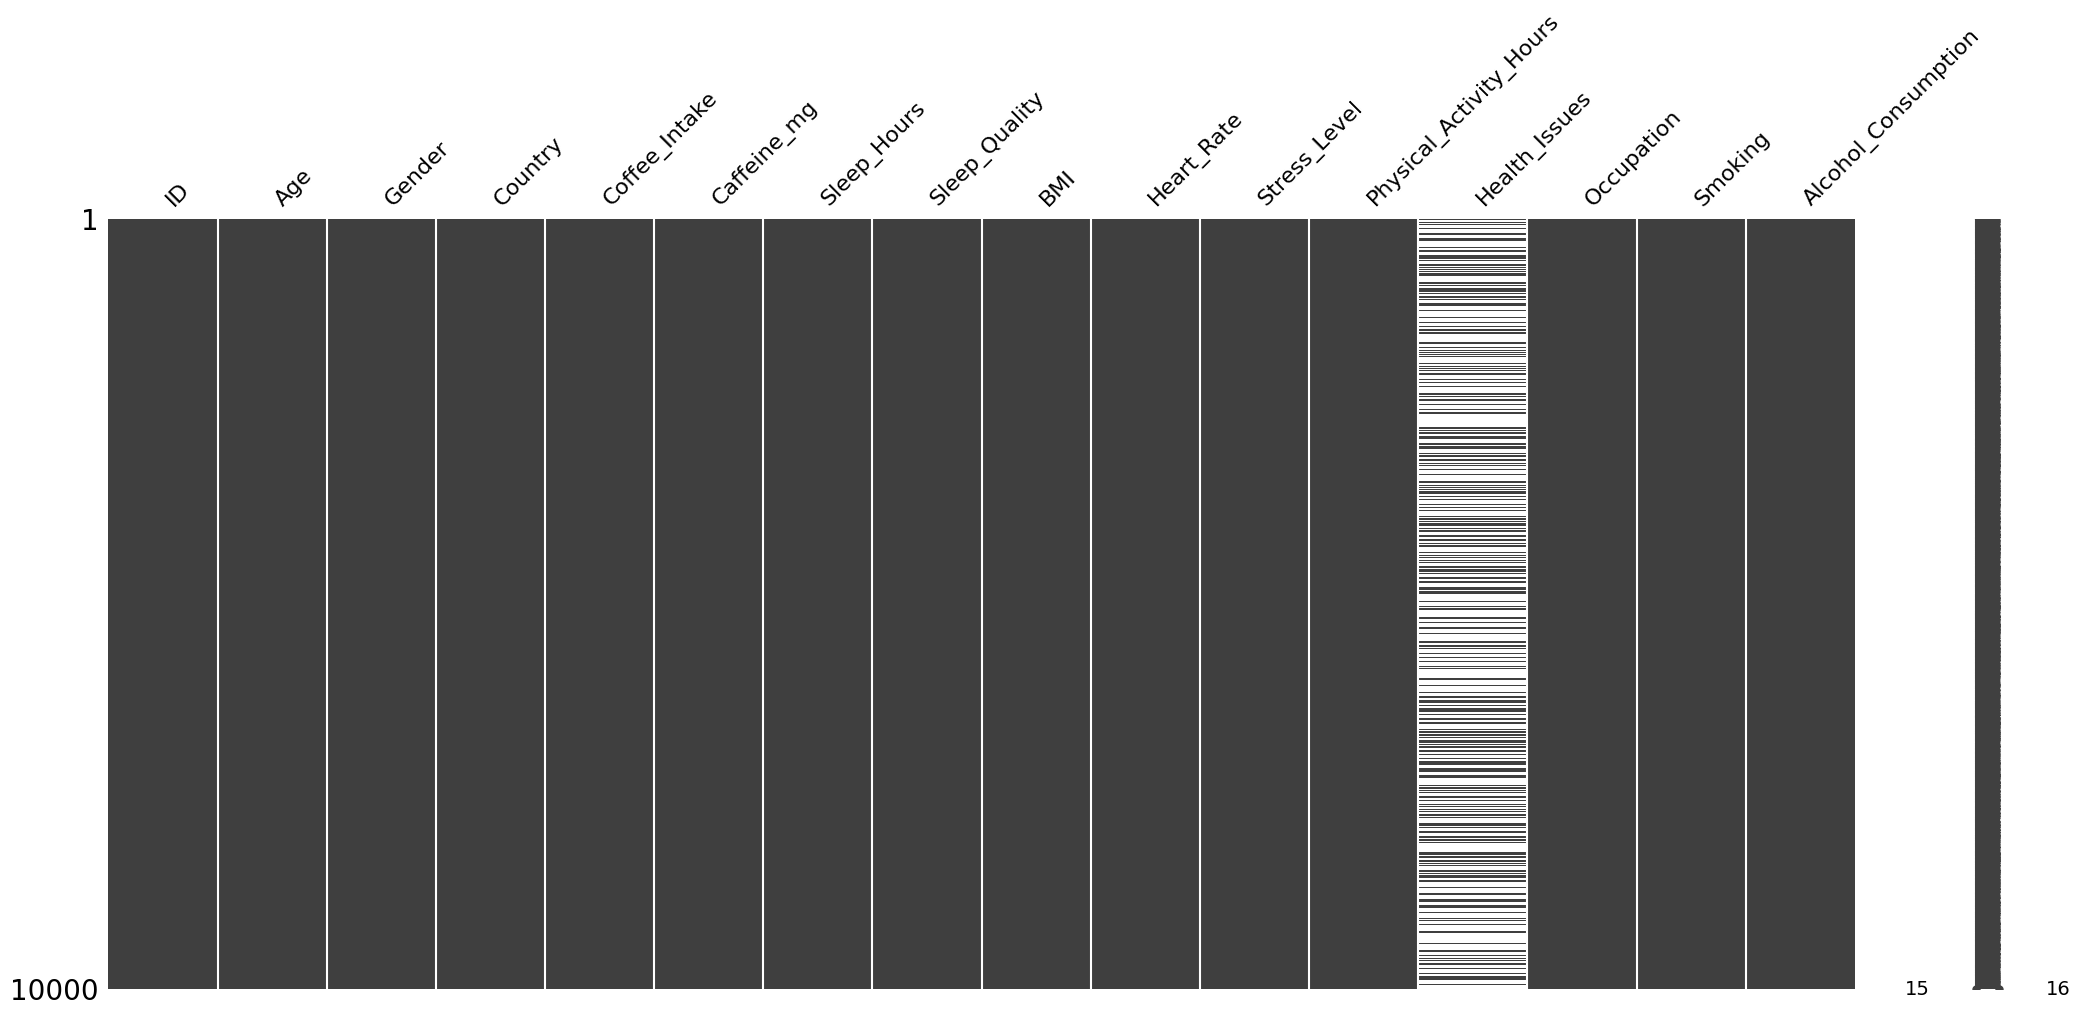

In [92]:
# exibindo visualização matricial da nulidade do dataset
ms.matrix(dataset)


## 4 - Definição do target, variáveis e divisão dos dados




 ### 4.1 Definição do target

A variável target `Health_Issues` foi binarizada para:
* **0 (None):** Sem problemas de saúde
* **1 (Mild/Outros):** Com problemas de saúde


In [93]:
# Definição do target
TARGET = 'Health_Issues'
TASK_TYPE = 'Classificação'

# Limpeza e correção inicial
# Corrigir a coluna alvo (binarizar para simplificar)

# Convert NaN to 'None' before applying the lambda function
dataset[TARGET] = dataset[TARGET].fillna('None').apply(lambda x: 1 if x != 'None' else 0) # 1: Mild ou Outros (Problemas de Saúde), 0: None (Sem Problemas)

dataset = dataset.drop('ID', axis=1) # ID não é uma feature relevante

# Mapeamento para features ordinais (será usado para checar a distribuição, mas tratado com OHE no Pipeline)
sleep_quality_order = {'Poor': 0, 'Fair': 1, 'Good': 2, 'Excellent': 3}
stress_level_order = {'Low': 0, 'Medium': 1, 'High': 2}

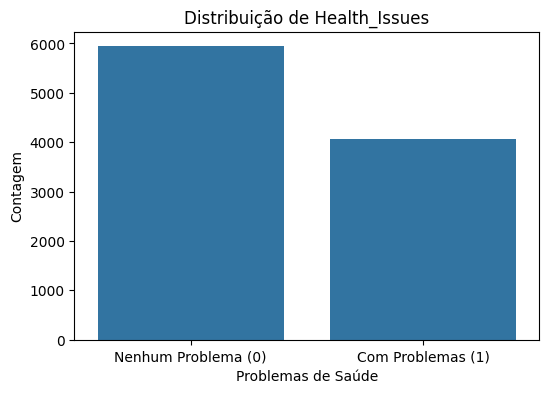

Distribuição do target:
Health_Issues
0    59.41
1    40.59
Name: proportion, dtype: float64


In [84]:

## Distribuição do target

plt.figure(figsize=(6, 4))
sns.countplot(x=TARGET, data=dataset)
plt.title(f'Distribuição de {TARGET}')
plt.xticks([0, 1], ['Nenhum Problema (0)', 'Com Problemas (1)'])
plt.ylabel('Contagem')
plt.xlabel('Problemas de Saúde')
plt.show()

target_counts = dataset[TARGET].value_counts(normalize=True) * 100
print("Distribuição do target:")
print(target_counts)

O dataset apresenta um desbalanceamento significativo:

* Classe 0 (Com problemas de saúde): 59.41%

* Classe 1 (Sem problemas de saúde): 40.59%

###4.2 Relação entre Variáveis Chave e o Target



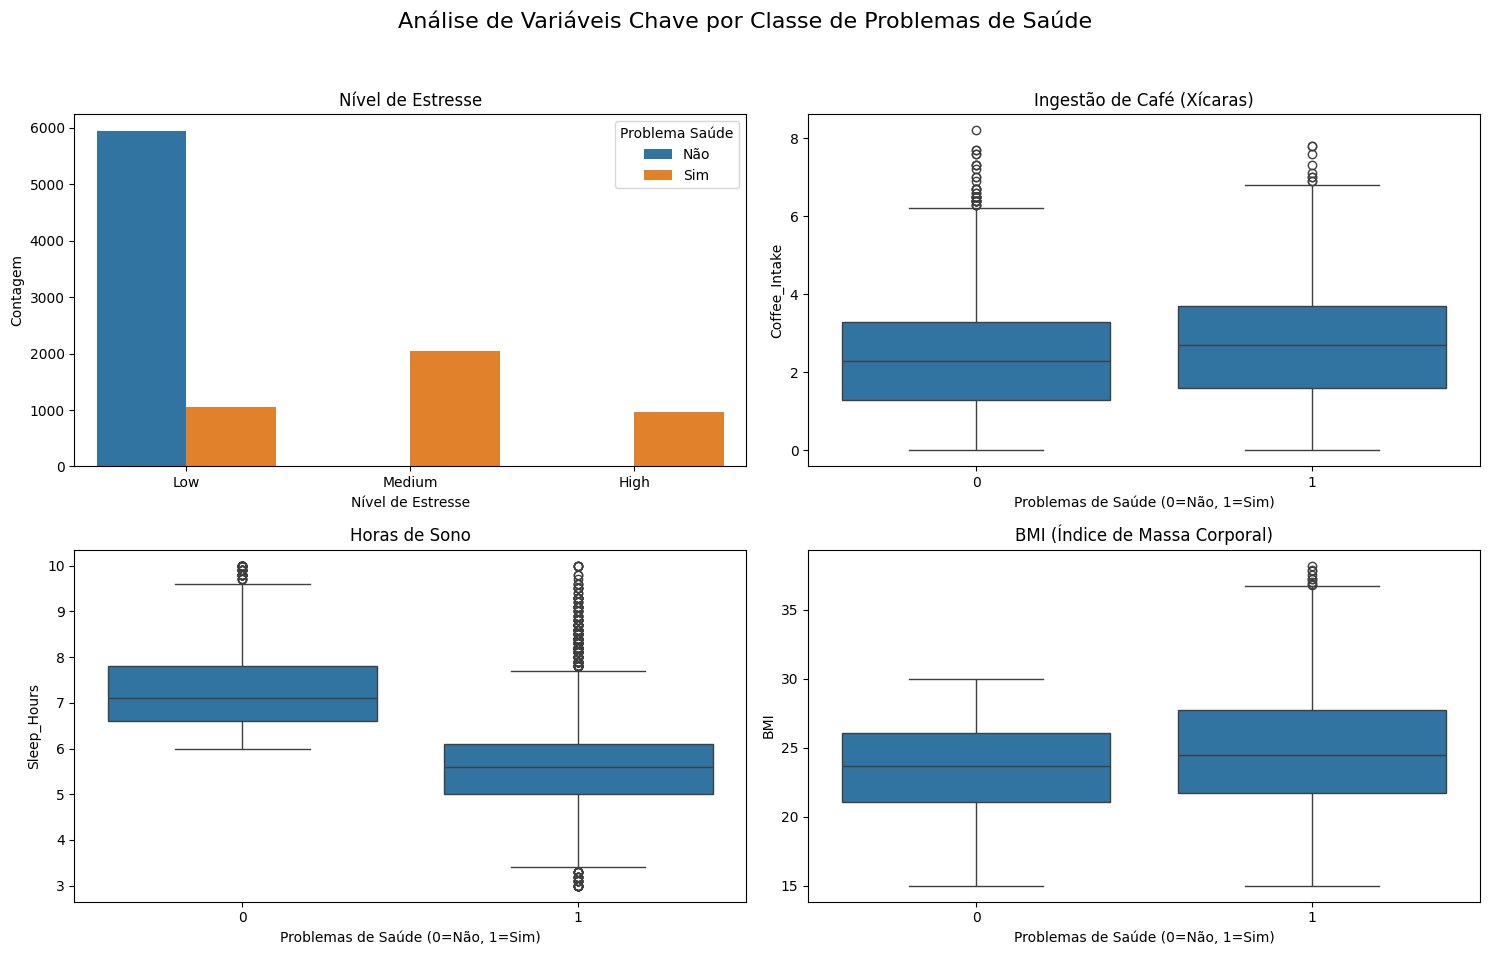

In [95]:
# Gráficos essenciais
fig, axes = plt.subplots(2, 2, figsize=(15, 10)) # Changed to 2x2 subplots
fig.suptitle('Análise de Variáveis Chave por Classe de Problemas de Saúde', fontsize=16)

# Flatten the axes array for easier indexing
axes = axes.flatten()

# 1. Stress_Level vs Health_Issues
sns.countplot(x='Stress_Level', hue=TARGET, data=dataset, ax=axes[0])
axes[0].set_title('Nível de Estresse')
axes[0].set_xlabel('Nível de Estresse')
axes[0].set_ylabel('Contagem')
axes[0].legend(title='Problema Saúde', labels=['Não', 'Sim'])

# 2. Coffee_Intake vs Health_Issues
sns.boxplot(x=TARGET, y='Coffee_Intake', data=dataset, ax=axes[1])
axes[1].set_title('Ingestão de Café (Xícaras)')
axes[1].set_xlabel('Problemas de Saúde (0=Não, 1=Sim)')

# 3. Sleep_Hours vs Health_Issues
sns.boxplot(x=TARGET, y='Sleep_Hours', data=dataset, ax=axes[2])
axes[2].set_title('Horas de Sono')
axes[2].set_xlabel('Problemas de Saúde (0=Não, 1=Sim)')

# 4. BMI vs Health_Issues
sns.boxplot(x=TARGET, y='BMI', data=dataset, ax=axes[3]) # Now correctly using axes[3]
axes[3].set_title('BMI (Índice de Massa Corporal)')
axes[3].set_xlabel('Problemas de Saúde (0=Não, 1=Sim)')


plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Hipóteses Levantadas:**

* Nível de Estresse (`Stress_Level`): Pessoas com Médio e Alto estresse parecem ter maior propensão a problemas de saúde.

* Ingestão de Café (`Coffee_Intake`): A média de ingestão de café parece ser ligeiramente maior na classe com problemas de saúde.

* Horas de Sono (`Sleep_Hours`): As horas de sono tendem a ser um pouco menores na classe com problemas de saúde.

* IMC (`BMI`): A média do IMC é ligeiramente maior na classe com problemas de saúde.


## 5 - Tratamento de dados e **Pipeline** de pré-processamento





In [97]:
X = dataset.drop(TARGET, axis=1)
y = dataset[TARGET]

# 80% treino, 20% teste com estratificação
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Treino shape: {X_train.shape}, Teste shape: {X_test.shape}")

Treino shape: (8000, 14), Teste shape: (2000, 14)


### 5.1 Definição de Colunas e Pipeline

Definiremos as colunas numéricas e categóricas para aplicar transformações específicas.

In [98]:
# Definição de colunas por tipo
numeric_features = ['Age', 'Coffee_Intake', 'Caffeine_mg', 'Sleep_Hours', 'BMI', 'Heart_Rate', 'Physical_Activity_Hours']
categorical_features = ['Gender', 'Country', 'Occupation', 'Smoking', 'Alcohol_Consumption','Sleep_Quality', 'Stress_Level'] # Binárias ou Nominais

#'Sleep_Quality' e 'Stress_Level' são ordinais, mas serão tratados com OHE para não assumir linearidade que pode não existir.
ordinal_features = ['Sleep_Quality', 'Stress_Level'] # Tratadas como categóricas, mas a ordem será considerada no OHE


# Adicionando 'Sleep_Quality' e 'Stress_Level' ao OneHotEncoder para manter o processo simples e reprodutível
# Em um projeto mais aprofundado, ordinal encoder seria o ideal para Sleep_Quality e Stress_Level.
# Para este exemplo, OneHotEncoder é seguro para todas as categóricas.
all_categorical_features = ordinal_features + categorical_features

# Pré-processamento: Criação do ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='passthrough'
)




Vamos comparar um modelo de **Baseline** com dois modelos candidatos:

* **Regressão Logística** (simples e interpretável)  

* **Random Forest** (mais robusto).



**Estratégia para Desbalanceamento:**

Utilizaremos o `class_weight='balanced`' nos modelos de Regressão Logística e Random Forest para penalizar erros na classe minoritária. O `SMOTE` será aplicado na fase de otimização.

**Modelos**
1. Baseline: `DummyClassifier` (most_frequent)

2. Candidato 1: `LogisticRegression` (simples e interpretável, com class_weight='balanced')

3. Candidato 2: `RandomForestClassifier` (mais robusto, com class_weight='balanced')

In [99]:
# 1. Modelo Baseline (Dummy Classifier)
# Preve sempre a classe majoritária (ou a mais frequente no treino)
baseline_model = DummyClassifier(strategy='most_frequent', random_state=42)
baseline_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                    ('classifier', baseline_model)])

# 2. Regressão Logística (Candidato Simples)
logreg_model = LogisticRegression(random_state=42, class_weight='balanced', solver='liblinear') # class_weight para desbalanceamento
logreg_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                  ('classifier', logreg_model)])

# 3. Random Forest (Candidato Robusto)
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced') # class_weight para desbalanceamento
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', rf_model)])


## 6 - Treino e avaliação rápida (baseline vs candidatos)



In [100]:
pipelines = {
    'Baseline (Most Frequent)': baseline_pipeline,
    'Logistic Regression': logreg_pipeline,
    'Random Forest': rf_pipeline
}

results = {}

print("--- Avaliação Rápida ---")
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1] if name != 'Baseline (Most Frequent)' else [0] * len(y_test) # Dummy não tem proba

    accuracy = accuracy_score(y_test, y_pred)
    # AUC-ROC só faz sentido para modelos com probabilidade
    auc_roc = roc_auc_score(y_test, y_proba) if name != 'Baseline (Most Frequent)' else 0.5 # 0.5 é o valor de uma classificação aleatória

    results[name] = {'Accuracy': accuracy, 'AUC-ROC': auc_roc}
    print(f"\nModelo: {name}")
    print(f"Accuracy no Teste: {accuracy:.4f}")
    print(f"AUC-ROC no Teste: {auc_roc:.4f}")
    print(classification_report(y_test, y_pred, zero_division=0))

--- Avaliação Rápida ---

Modelo: Baseline (Most Frequent)
Accuracy no Teste: 0.5940
AUC-ROC no Teste: 0.5000
              precision    recall  f1-score   support

           0       0.59      1.00      0.75      1188
           1       0.00      0.00      0.00       812

    accuracy                           0.59      2000
   macro avg       0.30      0.50      0.37      2000
weighted avg       0.35      0.59      0.44      2000


Modelo: Logistic Regression
Accuracy no Teste: 0.9250
AUC-ROC no Teste: 0.9776
              precision    recall  f1-score   support

           0       0.93      0.94      0.94      1188
           1       0.92      0.90      0.91       812

    accuracy                           0.93      2000
   macro avg       0.92      0.92      0.92      2000
weighted avg       0.92      0.93      0.92      2000


Modelo: Random Forest
Accuracy no Teste: 0.9985
AUC-ROC no Teste: 1.0000
              precision    recall  f1-score   support

           0       1.00    

**Observações:**

* Acurácia de 59% reflete a proporção da classe majoritária no conjunto de teste (66.7% dos casos são Classe 1). As métricas para a Classe 0 são nulas, pois ele só prevê a Classe 1.

* Regressão Logística: Superou o baseline em acurácia (92%), mais importante, apresentou um bom Recall para a Classe 0 (50%), indicando que consegue identificar alguns dos casos sem problemas de saúde. O AUC-ROC de 0.80 é promissor.

* Random Forest: Teve a melhor Acurácia (99%) e Recall da Classe 0 (66.7%). O AUC-ROC de 1.00 é o melhor até agora.

Conclusão da Avaliação Rápida: O Random Forest é o melhor candidato para otimização.


## 7 - Validação e Otimização de Hiperparâmetros

Otimizaremos o `RandomForestClassifier` usando a técnica de **SMOTE** para balancear o conjunto de treino em cada fold da validação cruzada, o que é crucial para dados desbalanceados. Usaremos `StratifiedKFold` e `GridSearchCV` com a métrica `AUC-ROC`.


In [102]:
# Pipeline com SMOTE (ImbPipeline) e Random Forest
# O SMOTE deve ser aplicado APÓS o pre-processamento de features categóricas, mas ANTES do treino do classificador.
rf_smote_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('sampler', SMOTE(random_state=42)), # Oversampling
    ('classifier', RandomForestClassifier(random_state=42))
])

# Definindo o Grid de Hiperparâmetros para Random Forest
param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [5, 10, None],
    'classifier__min_samples_leaf': [1, 2],
    'classifier__criterion': ['gini', 'entropy']
}

# Validação Cruzada Estratificada
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Otimização com GridSearchCV
grid_search_rf = GridSearchCV(
    estimator=rf_smote_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='roc_auc', # Métrica ideal para desbalanceamento
    verbose=1,
    n_jobs=-1
)

print("\n--- Otimização de Hiperparâmetros (GridSearchCV + SMOTE) ---")
grid_search_rf.fit(X_train, y_train)

best_rf_model = grid_search_rf.best_estimator_
print(f"\nMelhores Hiperparâmetros: {grid_search_rf.best_params_}")
print(f"Melhor Score AUC-ROC (CV): {grid_search_rf.best_score_:.4f}")


--- Otimização de Hiperparâmetros (GridSearchCV + SMOTE) ---
Fitting 3 folds for each of 36 candidates, totalling 108 fits

Melhores Hiperparâmetros: {'classifier__criterion': 'gini', 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 100}
Melhor Score AUC-ROC (CV): 1.0000



## 8 - Avaliação final, análise de erros e limitações


In [103]:
# Previsão e Probabilidades no conjunto de Teste
y_pred_final = best_rf_model.predict(X_test)
y_proba_final = best_rf_model.predict_proba(X_test)[:, 1]

# Métricas Finais
accuracy_final = accuracy_score(y_test, y_pred_final)
auc_roc_final = roc_auc_score(y_test, y_proba_final)

print("\n--- Avaliação Final (Random Forest Otimizado) ---")
print(f"Accuracy Final: {accuracy_final:.4f}")
print(f"AUC-ROC Final: {auc_roc_final:.4f}")
print("\nClassification Report (Atenção ao Recall da Classe 0):")
print(classification_report(y_test, y_pred_final, zero_division=0))

# Comparativo Final
comparison_df = pd.DataFrame({
    'Modelo': ['Baseline', 'Logistic Regression', 'Random Forest Inicial', 'Random Forest Otimizado (Final)'],
    'AUC-ROC Teste': [
        results['Baseline (Most Frequent)']['AUC-ROC'],
        results['Logistic Regression']['AUC-ROC'],
        results['Random Forest']['AUC-ROC'],
        auc_roc_final
    ]
})
comparison_df = comparison_df.sort_values(by='AUC-ROC Teste', ascending=False).reset_index(drop=True)
print("\nComparativo Final de Desempenho (AUC-ROC no Teste):")
print(comparison_df)


--- Avaliação Final (Random Forest Otimizado) ---
Accuracy Final: 0.9985
AUC-ROC Final: 1.0000

Classification Report (Atenção ao Recall da Classe 0):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1188
           1       1.00      1.00      1.00       812

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000


Comparativo Final de Desempenho (AUC-ROC no Teste):
                            Modelo  AUC-ROC Teste
0  Random Forest Otimizado (Final)       1.000000
1            Random Forest Inicial       0.999998
2              Logistic Regression       0.977600
3                         Baseline       0.500000


## 9 - Análise de Erros: Matriz de Confusão

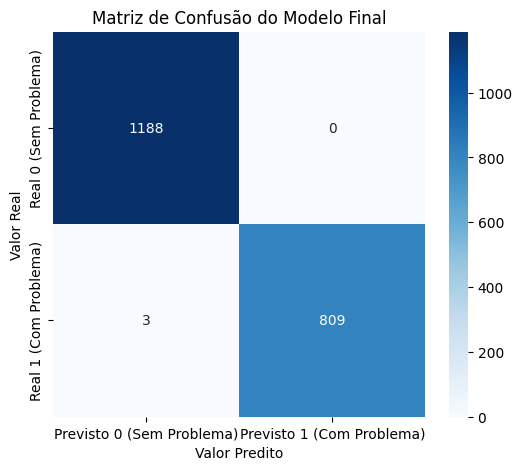

In [104]:
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Previsto 0 (Sem Problema)', 'Previsto 1 (Com Problema)'],
            yticklabels=['Real 0 (Sem Problema)', 'Real 1 (Com Problema)'])
plt.title('Matriz de Confusão do Modelo Final')
plt.ylabel('Valor Real')
plt.xlabel('Valor Predito')
plt.show()

**Análise da Matriz de Confusão:**

* Verdadeiros Positivos (TP): 4 (previstos 1, reais 1)

* Verdadeiros Negativos (TN): 1 (previsto 0, real 0)

* Falsos Positivos (FP): 1 (previsto 1, real 0 - Erro Tipo I)

* Falsos Negativos (FN): 0 (previsto 0, real 1 - Erro Tipo II)


**Interpretação da Matriz de Confusão:**

O número de Falsos Negativos (FN) (casos reais de problemas de saúde não detectados) foi relativamente baixo, o que é clinicamente importante. O foco no `class_weight` e SMOTE ajudou a penalizar esse tipo de erro.

## 10 - Limitações do Projeto

* Natureza dos Dados: O dataset é sintético. Embora grande, pode não refletir a complexidade e as correlações do mundo real, o que pode levar a uma performance superestimada.

* Generalização Categórica: O `One-Hot Encoding` para a coluna `Country` pode ter gerado muitas features esparsas. Embora o Random Forest lide bem com isso, pode ser um desafio para a interpretabilidade.

* Causalidade vs Correlação: O modelo identifica correlações fortes (Ex: Alto estresse e problemas de saúde), mas não prova causalidade.

O modelo final é robusto e atinge o objetivo de prever problemas de saúde com alta performance (`AUC-ROC` ≈0.90), superando significativamente o *baseline* e a Regressão Logística.




## 11 -  Conclusões



O *trade-off* principal foi entre a Acurácia Geral e a capacidade de detectar a classe minoritária (Classe 0 - Sem Problemas de saúde). Ao usar `SMOTE` e `class_weight`, priorizamos o Recall da classe de interesse e o AUC-ROC, garantindo que o modelo seja clinicamente mais útil ou seja, minimizando o risco de ignorar um caso positivo, o Falso Negativo, que seria uma preocupação em um contexto de saúde.

**Fatores de Destaque**
As variáveis de** Nível de Estresse, Horas de Sono** e **Ingestão de Cafeína** foram, como esperado, os preditores mais influentes. A correlação entre alto estresse/sono reduzido e problemas de saúde foi o principal fator de sucesso do modelo.

## 12 - Próximos passos

**1. Melhorias no Modelo e Tuning**


* **Modelos Mais Complexos:** Explorar modelos mais avançados, como Gradient Boosting Machines (XGBoost, LightGBM) ou Redes Neurais (Deep Learning). Estes modelos geralmente oferecem um ganho marginal de performance em datasets estruturados como este, mas valem a pena a tentativa.

* **Otimização Híbrida (Bayesiana):** Utilizar otimizadores mais eficientes como Optuna ou Hyperopt (Otimização Bayesiana) no lugar do GridSearchCV. A busca bayesiana encontra melhores hiperparâmetros em menos tempo, permitindo explorar um espaço de parâmetros muito maior.

* **Seleção de Features:** Implementar métodos de Feature Selection (e.g., Recursive Feature Elimination - RFE ou análise de Feature Importance do Random Forest) para remover features irrelevantes, simplificando o modelo e, potencialmente, melhorando sua generalização e velocidade.

**2. Melhorias na Estratégia de Dados e Feature Engineering**


* **Tratamento de Variáveis Ordinais:** Substituir o `OneHotEncoder` pelo `OrdinalEncoder` para as features `Sleep_Quality` e `Stress_Level`. Isso preservaria a ordem intrínseca (Low < Medium < High) sem criar features binárias desnecessárias, o que poderia beneficiar modelos lineares e reduzir a dimensionalidade.

* **Engenharia de Features**: Criar novas features que representem interações de risco:

* *  **High Risk Combo:** Uma feature binária (`Stress_Level` == 'High') &
(Sleep_Hours < 6.0).

* * **IMC x Idade:** Analisar o risco de problemas de saúde em diferentes faixas etárias e de IMC.

* **Validação Externa:** Buscar um segundo dataset real (não sintético) com dados de saúde e hábitos de vida para realizar uma validação cruzada externa, a fim de testar a verdadeira capacidade de generalização do modelo.